# Descenso de Gradiente

Recursos: 
- https://youtu.be/IHZwWFHWa-w?si=xFcdVV36dmh4xRxl
- https://youtu.be/FeEUeX0NlDg?si=KVZCC9VCbThhx0VL

Tenemos una función $L(\theta)$ que mide qué tan mal se ajusta el modelo a los datos.

Como el gradiente $\nabla L(\theta)$ indica en qué dirección sube más rápido la función, es decir, en qué dirección se ajusta peor, queremos movernos en la dirección contraria para **encontrar parámetros mejores**. Nuestros nuevos parámetros serán: 

$$\theta \leftarrow \theta - \alpha \cdot \nabla L(\theta)$$

La función de corrección es el error cuadrático medio:

$$L(a, b) = \frac{1}{N} \sum_{i=1}^{N} (y_i - (ax_i + b))^2$$

El gradiente se calcula con las derivadas parciales:

$$\frac{\partial L}{\partial a} = -\frac{2}{N} \sum_{i=1}^{N} (y_i - (ax_i + b)) \cdot x_i$$

$$\frac{\partial L}{\partial b} = -\frac{2}{N} \sum_{i=1}^{N} (y_i - (ax_i + b))$$

Se calculan los parámetros nuevos:

$$a \leftarrow a - \alpha \cdot \frac{\partial L}{\partial a}$$

$$b \leftarrow b - \alpha \cdot \frac{\partial L}{\partial b}$$

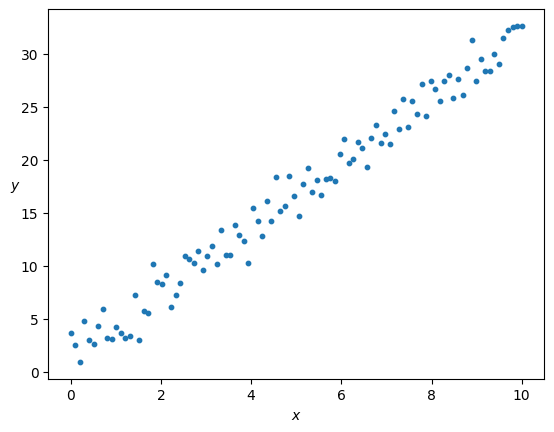

In [6]:
# generamos valores aleatorios
import numpy as np 
import matplotlib.pyplot as plt

np.random.seed(67)

x = np.linspace(0,10,100)
y = 3*x+2+np.random.randn(100)*1.5


plt.xlabel("$x$",)
plt.ylabel("$y$", rotation = 0)

plt.scatter(x,y,s= 10)
plt.show()



### El proceso de optimización:

$$\theta_{n} = \theta_{n-1} - \alpha \nabla L(\theta_{n-1})$$

Queremos optimizar **a**, la pendiente de nuestra recta, y **b**, el corte con el eje y.

$$\theta = \begin{bmatrix}a\\ b\end{bmatrix}$$

La ecuación de actualización queda:

$$\begin{bmatrix} a_{n}\\ b_{n}\end{bmatrix}= \begin{bmatrix} a_{n-1}\\ b_{n-1} \end{bmatrix}- \alpha \nabla L\!\left(\begin{bmatrix}a_{n-1}\\ b_{n-1}\end{bmatrix}\right)$$

Que se simplifica:

$$\begin{bmatrix}a_{n}\\ b_{n}\end{bmatrix}= \begin{bmatrix}a_{n-1}\\ b_{n-1}\end{bmatrix}- \alpha\frac{2}{N}\, x^T\bigl((a_{n-1}\cdot x + b_{n-1})-y\bigr)$$

In [ ]:
a = 0 
b = 0 
n = 1000
N = len(x)

L = []

alpha = 0.01

for paso in range(n):
    l = (1/N)* np.sum((y-(a*x+b))**2)
    L.append(l)
    grad_a = (2/N)*x@((a*x+b)-y)
    grad_b = (2/N)*np.sum((a*x+b)-y)
    a = a - alpha * grad_a
    b = b - alpha * grad_b



print(a)
print(b)

3.0478666192917556
1.5069495527194032


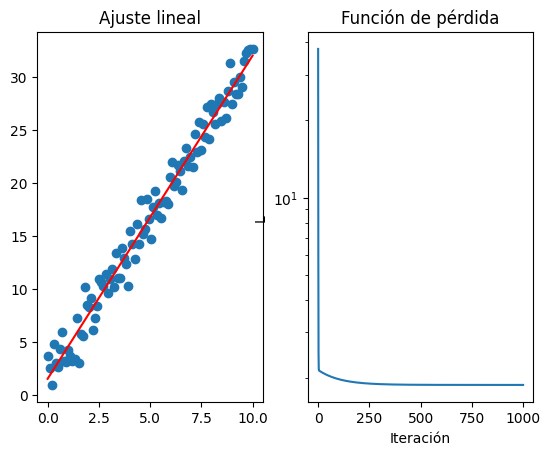

In [24]:
fig, ax = plt.subplots(1,2)

ax[0].set_title("Ajuste lineal")
ax[0].plot(x,a*x+b,color = "red")
ax[0].scatter(x,y)

ax[1].set_title("Función de pérdida")
ax[1].set_xlabel("Iteración")
ax[1].set_ylabel("L")
ax[1].plot(L)
ax[1].set_yscale("log")
plt.show()